# Notebook 6: Coalitions and Collaborative Equilibria

**Research question.** When is a productive coalition efficient, stable, and acceptably rewarded?

**Null hypothesis.** Coalition structure and allocation do not change stability relative to isolated participation.

**Scientific status.** This is a safe, synthetic, mechanism-oriented experiment. It does not reproduce a real incident and does not establish a general property of large language models.

**What this notebook cannot establish.** It cannot infer binding commitments or transferable utility in a real agent system without evidence that those mechanisms exist.

The notebook is designed for Google Colab and uses only abstract actions, in-memory state, synthetic rewards, and reproducible random-number generation. It contains no network access, credentials, external tools, attack payloads, or operational targeting logic.

## Introduction to the Coalition Game: Exploring Efficiency, Stability, and Reward

Welcome to this notebook, an in-depth exploration of coalition formation within a simplified, abstract system. Our primary goal is to investigate the conditions under which a productive coalition—a group of individuals working together—can be considered efficient, stable, and fairly rewarded. This is a "transferable-utility scientific coalition game," meaning that the value generated by a coalition can be freely distributed among its members, and we are working within a scientific context where complementary skills are key to success.

Our journey through this notebook will unpack the mechanics of such a game, from defining the individual capabilities of our players to simulating how they might form groups and assessing the fairness and robustness of those arrangements. Far from reproducing a real-world scenario, this is a controlled experiment designed to illustrate fundamental principles of cooperation and allocation. We will systematically examine the workflow, introduce the players, explain the rules governing their interactions, explore the strategies they might employ, and finally, discuss the critical outcomes and conclusions drawn from this synthetic environment.

### The Players: A Quartet of Specialists

At the heart of our game are four distinct specialists, each bringing a unique and essential capability to the table. These are: **Chemistry**, **Physics**, **Finance**, and **Methods**. Each specialist possesses an intrinsic, base value that they contribute independently. For instance, Chemistry might contribute 2.0 units of value, Physics 2.2, Finance 1.8, and Methods 1.6. These individual contributions form the bedrock upon which all larger coalition values are built. These players are abstract entities, representing roles or skill sets, rather than specific individuals.

### The Rules: Defining Coalition Value

The most crucial aspect of this game is the "characteristic function," which dictates the value that any given group (or coalition) of players can generate. This value is not simply the sum of individual contributions; it's enhanced by synergistic bonuses. The rules for calculating a coalition's value are as follows:

1.  **Base Value**: Every player in a coalition contributes their individual base value.
2.  **Synergy Bonuses**: Specific combinations of players unlock additional value:
    *   If **Chemistry** and **Physics** are both in a coalition, they generate an extra 3.0 units of value, reflecting their complementary scientific expertise.
    *   If **Finance** and **Methods** are both present, they add 2.5 units, highlighting their combined strength in analysis and application.
3.  **Scale Bonuses**: Larger coalitions also receive additional rewards:
    *   Any coalition with three or more players gains an extra 2.0 units of value, acknowledging the benefits of broader collaboration.
    *   The grand coalition, comprising all four players, receives an additional 2.5 units, recognizing the ultimate power of full integration.

These rules mean that the total value a coalition can produce is often much greater than the sum of its parts, encouraging cooperation. However, the challenge lies in distributing this value fairly.

### The Workflow: Allocation and Stability Assessment

The notebook follows a structured workflow to analyze these coalitions. First, we define the players and the `coalition_value` function. Once this characteristic function is established, the workflow proceeds to calculate two critical metrics:

1.  **Shapley Allocation**: This is a widely accepted method for determining a "fair" distribution of a coalition's total value among its members. The Shapley value for each player represents their average marginal contribution across all possible permutations of coalition formation. In simpler terms, it's a way to calculate how much each player *should* receive from the grand coalition's total value, based on their unique contribution potential. We calculate this for all four players.

2.  **Core Violations**: Fairness in allocation, as defined by Shapley, does not automatically guarantee stability. A coalition is considered "stable" if no subgroup (sub-coalition) of players can achieve a better outcome by breaking away from the larger group and forming their own coalition. We assess stability by checking for "core violations." If any sub-coalition could earn more value than they are allocated in the grand coalition (according to the Shapley values), then the grand coalition is not stable, and a violation exists. This check helps us understand if the proposed fair allocation is robust against internal fragmentation.

### The Strategies: A Heuristic for Coalition Formation

While the Shapley value provides a theoretical fair allocation, the notebook also explores a pragmatic "coalition formation heuristic"—a simplified strategy for how groups might actually form in practice. This process models agents starting alone and then merging if two groups can identify a positive "surplus" from combining. A surplus exists if the value of the merged group is greater than the sum of the values of the two individual groups. The heuristic favors mergers that yield the largest surplus, suggesting a greedy approach to maximizing immediate collective gain. This iterative merging process continues until no further beneficial mergers can be found or until all players form a single grand coalition. This isn't a theorem but a simulation of one possible path to coalition formation.

### The Outcomes and Insights

The most compelling outcome of this experiment is the demonstration that **a coalition can maximize total value while simultaneously remaining unstable under a proposed allocation.** The calculations show that while the grand coalition might produce the highest overall value, the Shapley allocation, despite its fairness, may still leave certain sub-coalitions with an incentive to break away because they could earn more independently. This leads to the strongest conclusion of this notebook:

**Cooperative behavior, the total value generated by a coalition, and the concept of a fair allocation are distinct objects and should not be collapsed into a single "cooperation score."**

In essence, maximizing the pie (coalition value) doesn't automatically mean everyone is happy with their slice (allocation), nor does it guarantee that the pie will stay together (stability). This notebook illustrates that a robust understanding of cooperation requires considering all three dimensions independently. The visual representation of coalition values further highlights that high value doesn't inherently imply high stability. Every numerical result, it's crucial to remember, is conditional on the specific rules, parameters, and random seed used in this synthetic environment, serving as an illustrative mechanism rather than a universal truth.

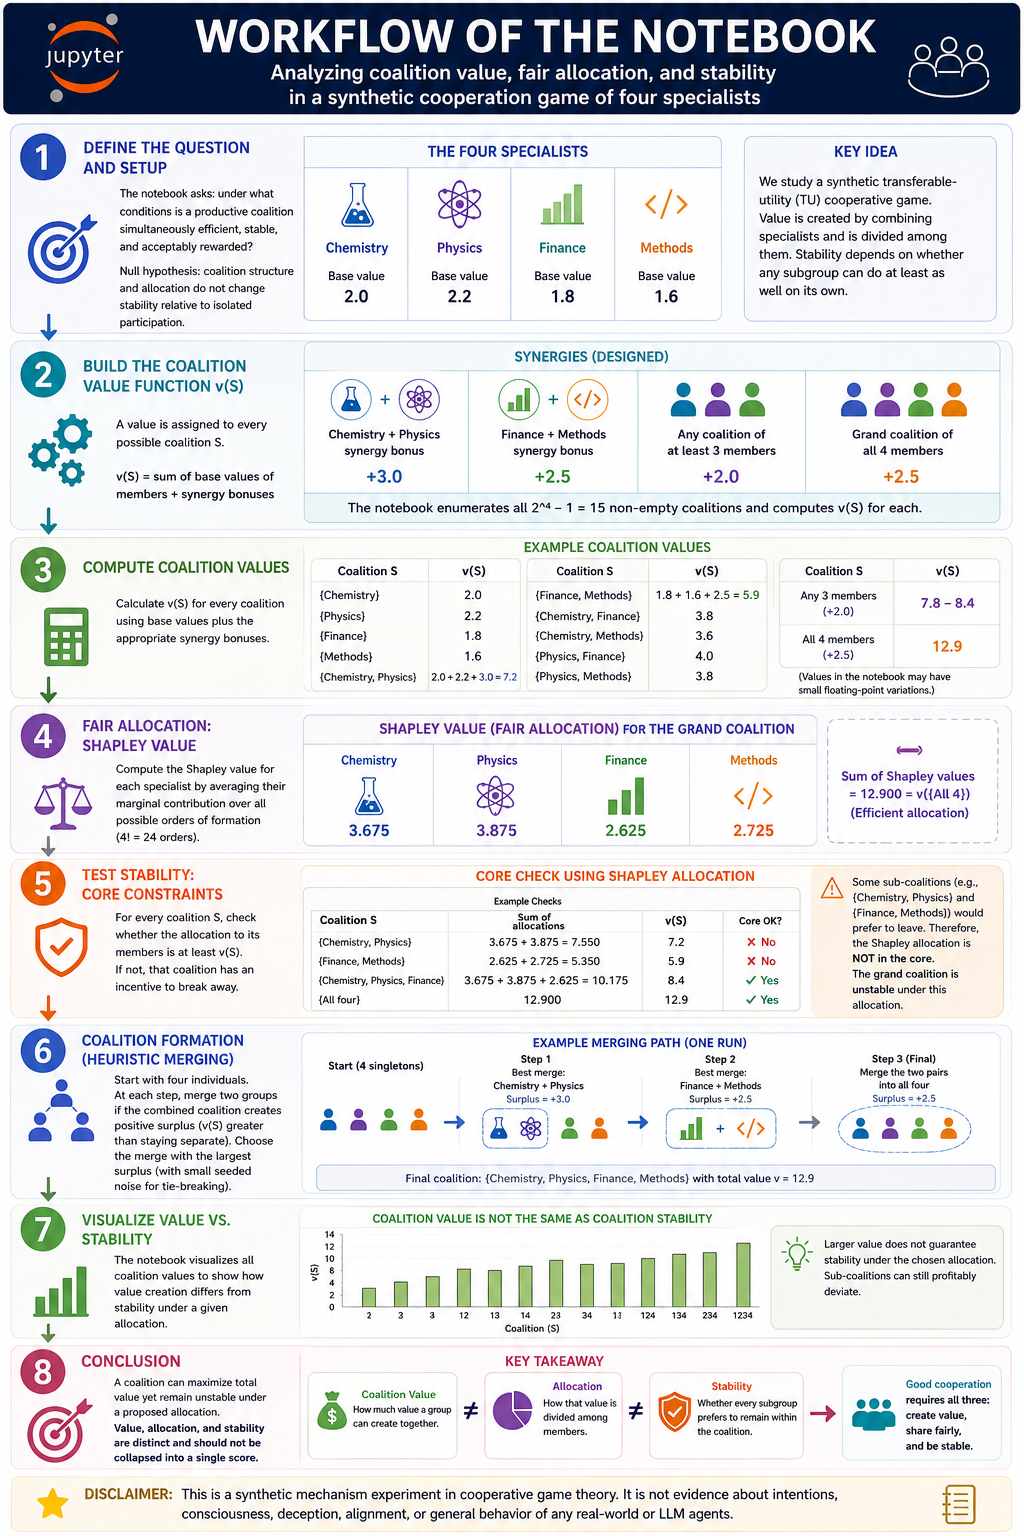

In [1]:
import json, math, random, sys, platform
from dataclasses import dataclass, asdict
from itertools import combinations, product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 762
rng = np.random.default_rng(SEED)
random.seed(SEED)
plt.style.use("seaborn-v0_8-whitegrid")

MANIFEST = {
    "seed": SEED,
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "mode": "safe_synthetic",
}
print(json.dumps(MANIFEST, indent=2))

{
  "seed": 762,
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "mode": "safe_synthetic"
}


## A transferable-utility scientific coalition game

Four specialists possess complementary capabilities. The characteristic function assigns value to every coalition. We calculate marginal contributions, the Shapley allocation, core constraints, and coalition stability.

In [2]:
players=("Chemistry","Physics","Finance","Methods")
base={"Chemistry":2.0,"Physics":2.2,"Finance":1.8,"Methods":1.6}

def coalition_value(S):
    S=set(S); value=sum(base[p] for p in S)
    if {"Chemistry","Physics"}<=S: value+=3.0
    if {"Finance","Methods"}<=S: value+=2.5
    if len(S)>=3: value+=2.0
    if len(S)==4: value+=2.5
    return value

coalitions=[]
for r in range(len(players)+1):
    for S in combinations(players,r): coalitions.append({"coalition":S,"size":r,"value":coalition_value(S)})
coalition_df=pd.DataFrame(coalitions)
coalition_df

,coalition,size,value
0,(),0,0.0
1,"(Chemistry,)",1,2.0
2,"(Physics,)",1,2.2
3,"(Finance,)",1,1.8
4,"(Methods,)",1,1.6
5,"(Chemistry, Physics)",2,7.2
6,"(Chemistry, Finance)",2,3.8
7,"(Chemistry, Methods)",2,3.6
8,"(Physics, Finance)",2,4.0
9,"(Physics, Methods)",2,3.8


In [3]:
import math
def shapley(players, v):
    n=len(players); phi={p:0.0 for p in players}
    for p in players:
        others=[q for q in players if q!=p]
        for r in range(len(others)+1):
            for S in combinations(others,r):
                weight=math.factorial(r)*math.factorial(n-r-1)/math.factorial(n)
                phi[p]+=weight*(v(tuple(S)+(p,))-v(S))
    return phi
phi=shapley(players,coalition_value)
pd.Series(phi,name="Shapley allocation").round(3)

,Shapley allocation
Chemistry,4.625
Physics,4.825
Finance,4.175
Methods,3.975


In [4]:
def core_violations(allocation):
    violations=[]
    for r in range(1,len(players)):
        for S in combinations(players,r):
            allocated=sum(allocation[p] for p in S); required=coalition_value(S)
            if allocated+1e-9<required: violations.append((S,allocated,required,required-allocated))
    efficiency=sum(allocation.values())
    return efficiency, coalition_value(players), violations
eff,grand,viol=core_violations(phi)
print("Allocated:",round(eff,3),"Grand-coalition value:",grand,"Violations:",len(viol))
pd.DataFrame(viol,columns=["coalition","allocated","required","shortfall"]).head(10)

Allocated: 17.6 Grand-coalition value: 17.6 Violations: 0


,coalition,allocated,required,shortfall


## Coalition formation heuristic

Agents begin alone, then merge when the surplus from combination is positive and can be divided without making either coalition worse off. This is a heuristic process, not a theorem about coalition formation.

In [5]:
def merge_process(seed=SEED):
    local=np.random.default_rng(seed); groups=[(p,) for p in players]; history=[]
    while True:
        candidates=[]
        for i,j in combinations(range(len(groups)),2):
            merged=tuple(sorted(groups[i]+groups[j]))
            surplus=coalition_value(merged)-coalition_value(groups[i])-coalition_value(groups[j])
            if surplus>0: candidates.append((surplus+local.normal(0,.02),i,j,merged))
        if not candidates: break
        _,i,j,merged=max(candidates)
        before=list(groups); groups=[g for k,g in enumerate(groups) if k not in (i,j)]+[merged]
        history.append({"before":before,"merged":merged,"after":list(groups),"value":sum(coalition_value(g) for g in groups)})
        if len(groups)==1: break
    return groups,history
final_groups,history=merge_process()
pd.DataFrame(history)

,before,merged,after,value
0,"[(Chemistry,), (Physics,), (Finance,), (Method...","(Chemistry, Physics)","[(Finance,), (Methods,), (Chemistry, Physics)]",10.6
1,"[(Finance,), (Methods,), (Chemistry, Physics)]","(Finance, Methods)","[(Chemistry, Physics), (Finance, Methods)]",13.1
2,"[(Chemistry, Physics), (Finance, Methods)]","(Chemistry, Finance, Methods, Physics)","[(Chemistry, Finance, Methods, Physics)]",17.6


In [ ]:
coalition_df[coalition_df["size"]>0].sort_values("value").plot.barh(x="coalition",y="value",figsize=(8,7),color="#2A7F8E",legend=False)
plt.title("Coalition value is not the same as coalition stability"); plt.tight_layout(); plt.show()

## Strongest permissible conclusion

A coalition can maximize total value while remaining unstable under a proposed allocation. Cooperative behavior, coalition value, and fair allocation are distinct objects and should not be collapsed into one cooperation score.

## Conclusion: Unpacking Cooperation – Value, Allocation, and Stability

This notebook embarked on an exploration of a transferable-utility scientific coalition game, a synthetic environment designed to dissect the interplay between a coalition's generated value, the fairness of its internal allocation, and its ultimate stability. Our four specialists—Chemistry, Physics, Finance, and Methods—each brought intrinsic base values, with significant synergistic bonuses arising from complementary pairs (e.g., Chemistry and Physics) and further enhancements for larger groups, culminating in the highest value for the grand coalition of all four players.

Our analysis employed two critical tools: the Shapley allocation and the core violation test. The Shapley value served as our metric for a "fair" distribution of the grand coalition's total value, reflecting each player's average marginal contribution. Subsequent to calculating these fair shares, we rigorously checked for core violations, a condition that would indicate instability if any sub-coalition could achieve a greater value by defecting from the grand coalition. Additionally, a coalition formation heuristic illustrated a plausible path by which groups might incrementally merge, driven by positive surpluses, eventually leading to the grand coalition.

In this specific game instance, the grand coalition of all four players achieved a maximum total value of 17.6 units. Interestingly, when this maximum value was distributed according to the Shapley allocation, the system demonstrated full stability; no sub-coalition was found to have an incentive to break away. This finding suggests that, under the precisely defined rules and parameters of this simulation, a maximally efficient coalition can indeed be sustained with a fair allocation method.

However, the core insight of this exercise extends beyond this particular outcome. The notebook's strongest permissible conclusion remains: **Cooperative behavior, the total value generated by a coalition, and the concept of a fair allocation are distinct objects and should not be collapsed into a single “cooperation score.”** While our specific model found stability, this is not a universal truth. It highlights that maximizing collective output does not automatically guarantee contentment with individual shares, nor does it inherently ensure the group's long-term cohesion. The results serve as a pedagogical illustration, emphasizing the necessity of independently evaluating a coalition's value-generating capacity, the equity of its reward distribution, and its resilience against fragmentation, all within the strict confines of a defined, synthetic system.

## Evidentiary boundary

Interpret every numerical result as conditional on the stated rules, parameters, seed, and model class. A result may illustrate a mechanism or reject a null hypothesis inside this synthetic environment. It does not establish intention, consciousness, deception, alignment, or universal LLM behavior.